# 250306 - testing sqrt rather than arcsin

In the literature, there is a common substitution that is made that I want to test out.

For Snell's Law, $n_i \sin \theta_i = n_t \sin \theta_t$, this can be rearranged to solve for $\theta_t$ like this:

$$\theta_t = \sin^{-1}\left( \frac{n_i}{n_t} \sin\theta_i \right)$$

But then we are often pluggin that $\theta_t$ into a cosine function for many of our calulations. Rather than doing that we can use the fact that

$$\cos^2(\theta) + \sin^2(\theta) = 1$$

So we can rearrage to get

$$\cos(\theta) = \sqrt{1-sin^2(\theta)}$$

and then substitute using Snell's to get

$$\cos(\theta_t) = \sqrt{1-\left(\frac{n_i}{n_t}\sin(\theta_i)\right)^2}$$

So here in the first part I compare this to the other way of doing it and decide that it is much faster. So we're going to switch even though it doesn't matter that much at the moment. 

## Also,

I am curious whether numpy can give us complex values. Numpy will give complex answers, but only if the input was provided as a complex number. So in the example below, when I put in `np.sqrt(-1)` then it returns `nan`, but if I give it `np.sqrt(-1+0j)` then it will return `1j`. So I'm not sure how well we can incorporate that into our process, or even whether we need to, but it is interesting.

## Although,

I suppose what this does mean is that all I need to do is change the 1 inside the radical of the function I have called `costht` and then that might handle complex numbers right there. I'll leave that to a future me.

In [1]:
%matplotlib widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
def funcPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[])
    line02, = ax0.plot([],[])
    line03, = ax0.plot([],[])
    line04, = ax0.plot([],[])
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperp, r$_s$', r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)
    def plot(ni=1, nt=1.5):
        output1 = func1(ni, nt, thi)
        output2 = func2(ni, nt, thi)
        output3 = func3(ni, nt, thi)
        output4 = func4(ni, nt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1))

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, thi):
    return(arcsin(ni/nt*sin(thi)))

def costht(ni, nt, thi):
    return(np.sqrt(1-(ni/nt*sin(thi))**2))

def rperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    return((ni/mui*cos_thi-nt/mut*cos_tht)/(ni/mui*cos_thi+nt/mut*cos_tht))

def rperp2(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    tht = snells(ni, nt, thi)
    
    return((ni/mui*cos(thi)-nt/mut*cos(tht))/(ni/mui*cos(thi)+nt/mut*cos(tht)))

def rperp3(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''

    return((ni/mui*cos(thi)-nt/mut*cos(arcsin(ni/nt*sin(thi))))/(ni/mui*cos(thi)+nt/mut*cos(arcsin(ni/nt*sin(thi)))))


def tperp(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light perpendicular to the 
    plane of incidence and therefore parallel to the interface
    of the material.

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)

    return((2*ni/mui*cos_thi)/(ni/mui*cos_thi+nt/mut*cos_tht))

def rpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    reflection coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    
    return((-nt/mut*cos_thi+ni/mui*cos_tht)/(ni/mui*cos_tht+nt/mut*cos_thi))

def tpara(ni, nt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, thi)
    
    return((2*ni/mui*cos_thi)/(ni/mui*cos_tht+nt/mut*cos_thi))

interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0), FloatSlider(value=1.5, description='n…

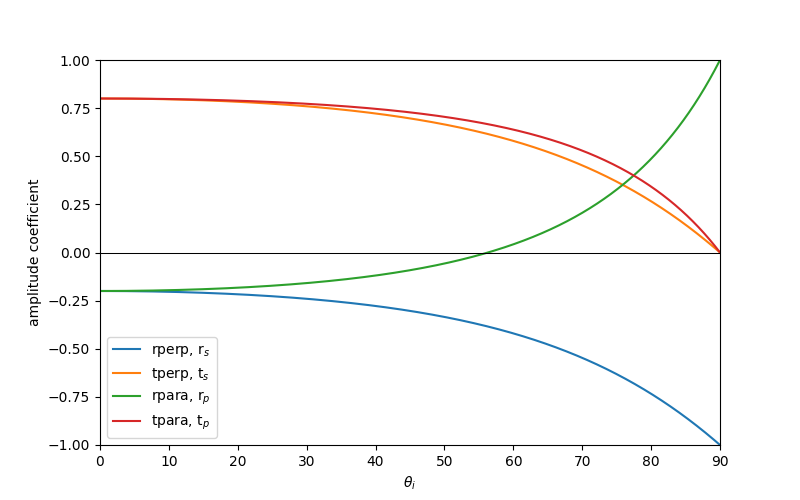

In [4]:
funcPlot(rperp, tperp, rpara, tpara)

In [37]:
%%timeit
thi1 = np.linspace(0.1,89.9,10000)
rperp(1, 1.5, thi1)

140 μs ± 445 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [38]:
%%timeit
thi2 = np.linspace(0.1,89.9,10000)
rperp2(1,1.5,thi2)

319 μs ± 2.22 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [39]:
%%timeit
thi3 = np.linspace(0.1,89.9,10000)
rperp3(1,1.5,thi3)

410 μs ± 7.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Can numpy give complex values?

sort of

In [43]:
np.sqrt(-1)

/tmp/ipykernel_76208/3438155168.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(-1)


nan

In [44]:
np.sqrt(-1+0j)

1j

In [41]:
(-1)**(1/2)

(6.123233995736766e-17+1j)